# 跆拳道动作识别（被试级 10 折交叉验证）—— 统一 notebook

所有模块按顺序写在独立单元格中，**从上到下依次运行**即可（等价于 `run_all.py`）。

- 数据根目录默认 `E:\yanjiusheng\datas\腿法\dataset`，可在 Setup 单元格用环境变量 `TAEKWONDO_DATA_ROOT` 覆盖。
- 可调参数集中在 Setup 单元格（`【可调参数】` 注释处）。
- 结果（CSV / PNG / npy）保存到当前目录的 `results/` 文件夹。
- 注意：`06`（SVM GridSearchCV）、`07`（深度学习，默认 30 epochs × 3 模型 × 10 折）、`08`（消融）耗时较长；快速验证可把 Setup 里的 `DL_EPOCHS` 调成 1。


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

# 数据目录：默认使用仓库的 data/ 目录（notebook 位于 code/ 下，即 ../data）
# 可用环境变量 TAEKWONDO_DATA_ROOT 覆盖
_cwd = Path.cwd()
DATA_ROOT = Path(os.environ.get(
    "TAEKWONDO_DATA_ROOT",
    str((_cwd / "data") if (_cwd / "data").exists() else (_cwd / ".." / "data")),
))
RESULTS_DIR = (_cwd / "results") if (_cwd / "results").exists() else (_cwd / ".." / "results")
RESULTS_DIR.mkdir(exist_ok=True)

CHANNELS = [
    "x_W", "y_W", "z_W", "x_rL", "y_rL", "z_rL", "x_rH", "y_rH", "z_rH",
    "x_lL", "y_lL", "z_lL", "x_lH", "y_lH", "z_lH",
]
SENSOR_GROUPS = {
    "waist": ["x_W", "y_W", "z_W"],
    "ankles": ["x_rL", "y_rL", "z_rL", "x_lL", "y_lL", "z_lL"],
    "wrists": ["x_rH", "y_rH", "z_rH", "x_lH", "y_lH", "z_lH"],
}
KICK2EN = {
    "左前踢": "Left Front Kick", "右前踢": "Right Front Kick",
    "左横踢": "Left Roundhouse Kick", "右横踢": "Right Roundhouse Kick",
    "左侧踢": "Left Side Kick", "右侧踢": "Right Side Kick",
    "左后踢": "Left Back Kick", "右后踢": "Right Back Kick",
}
CLASSES = list(KICK2EN.values()) + [
    "Left Straight Punch", "Right Straight Punch",
    "Left High Block", "Right High Block",
    "Left Middle Block", "Right Middle Block",
    "Left Low Block", "Right Low Block",
]
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

FS = 30.0  # 采样率 Hz

# 【可调参数】
RANDOM_STATE = 42
N_FOLDS = 10
N_TEST_SUBJECTS = 2
SVM_PARAM_GRID = {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"], "kernel": ["rbf"]}
GRID_CV = 5
RF_N_ESTIMATORS = 100
DL_EPOCHS = 30
DL_BATCH_SIZE = 32
DL_LR = 1e-3
DL_HIDDEN = 64
DL_DROPOUT = 0.3


## 01 数据加载：读取 4 个文件、解析 id、中英映射、合并统一数据集

In [2]:
def read_table(path):
    try:
        import openpyxl
        wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
        ws = wb.worksheets[0]
        rows = list(ws.iter_rows(values_only=True))
        wb.close()
        header = [str(h).strip() for h in rows[0]]
        return pd.DataFrame(rows[1:], columns=header)
    except Exception:
        return pd.read_csv(path, encoding="utf-8-sig")


def parse_id(id_str):
    action_raw, subject_id, trial = id_str.rsplit("_", 2)
    return action_raw, subject_id, trial


def load_dataset(root=DATA_ROOT):
    files = {
        "kick": (root / "data_kick_technique.csv",
                 root / "label_kick_technique.csv"),
        "punch": (root / "data_punch_technique.csv",
                  root / "label_punch_technique.csv"),
    }
    parts = []
    for region, (data_path, label_path) in files.items():
        data = read_table(data_path)
        label = read_table(label_path)
        data["id"] = data["id"].astype(str).str.strip()
        label["id"] = label["id"].astype(str).str.strip()
        assert set(data["id"].unique()) == set(label["id"].unique()), f"{region} id 不一致"
        parsed = data["id"].map(parse_id)
        action_raw = parsed.map(lambda t: t[0])
        subject = parsed.map(lambda t: t[1])
        trial = parsed.map(lambda t: int(t[2]))
        action = action_raw.map(lambda a: KICK2EN.get(a, a)) if region == "kick" else action_raw
        df = data.copy()
        df["subject_key"] = region + "_" + subject
        df["subject_id"] = subject
        df["region"] = region
        df["action"] = action
        df["trial"] = trial
        df["time"] = pd.to_numeric(df["time"]).astype(int)
        for c in CHANNELS:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        parts.append(df[["id", "subject_key", "subject_id", "region", "action", "trial", "time"] + CHANNELS])
    merged = pd.concat(parts, ignore_index=True)
    assert merged["action"].isin(CLASSES).all(), "存在未映射到 16 类的动作"
    return merged


def to_windows(df, channels=CHANNELS):
    df = df.sort_values(["id", "time"], kind="stable")
    n = len(df["id"].unique())
    arr = df[channels].to_numpy(dtype=np.float32)
    X = arr.reshape(n, 120, len(channels)).transpose(0, 2, 1)
    first = df.drop_duplicates("id")
    y = np.array([CLASS2IDX[a] for a in first["action"]], dtype=np.int64)
    meta = first[["id", "subject_key", "region", "action", "trial"]].reset_index(drop=True)
    return X, y, meta


df = load_dataset()
X, y, meta = to_windows(df)
print(f"样本 {len(y)}，输入形状 {X.shape}，类别 {len(CLASSES)}")
display(df.drop_duplicates("id").groupby("action").size().to_frame("n_samples"))


样本 1522，输入形状 (1522, 15, 120)，类别 16


,n_samples
action,
Left Back Kick,98
Left Front Kick,102
Left High Block,89
Left Low Block,89
Left Middle Block,89
Left Roundhouse Kick,102
Left Side Kick,99
Left Straight Punch,90
Right Back Kick,105


## 02 各通道统计与 ±6g 饱和检查

In [4]:
G_LIMIT = 6.0  # ±6g 饱和阈值


def channel_statistics(df):
    rows = []
    for c in CHANNELS:
        x = df[c].to_numpy(dtype=np.float64)
        mean, std = x.mean(), x.std(ddof=1)
        with np.errstate(invalid="ignore", divide="ignore"):
            z = (x - mean) / std if std > 0 else np.zeros_like(x)
            skew = float(np.mean(z ** 3)) if std > 0 else 0.0
            kurt = float(np.mean(z ** 4) - 3.0) if std > 0 else 0.0
        rows.append({
            "channel": c, "min": float(x.min()), "max": float(x.max()),
            "mean": float(mean), "std": float(std), "skew": skew, "kurtosis": kurt,
            "peak": float(np.max(np.abs(x))),
            "n_abs_ge_6g": int((np.abs(x) >= G_LIMIT).sum()),
            "frac_abs_ge_6g": float((np.abs(x) >= G_LIMIT).mean()),
        })
    return pd.DataFrame(rows)


def class_counts(df):
    return df.drop_duplicates("id").groupby("action").size().rename("n_samples").reset_index()


stats = channel_statistics(df)
counts = class_counts(df)
stats.to_csv(RESULTS_DIR / "channel_statistics.csv", index=False)
counts.to_csv(RESULTS_DIR / "class_counts.csv", index=False)
display(stats.round(4))
print(f"饱和(≥6g)最大比例 = {stats['frac_abs_ge_6g'].max():.4f}")


,channel,min,max,mean,std,skew,kurtosis,peak,n_abs_ge_6g,frac_abs_ge_6g
0,x_W,-1.723,4.070,0.9530,0.1871,-0.2810,16.9321,4.070,0,0.0000
1,y_W,-4.879,4.289,0.0488,0.2991,-0.0633,8.3939,4.879,0,0.0000
2,z_W,-3.012,2.570,0.0765,0.2365,-0.7309,6.2670,3.012,0,0.0000
3,x_rL,-5.523,7.996,1.0234,0.4387,5.0866,59.6960,7.996,183,0.0010
4,y_rL,-7.383,7.426,-0.0387,0.4895,-2.4330,34.6862,7.426,41,0.0002
5,z_rL,-6.004,7.004,0.1077,0.3814,1.8840,31.5552,7.004,8,0.0000
6,x_rH,-8.000,7.801,-0.6895,0.5282,-0.6986,21.4143,8.000,77,0.0004
7,y_rH,-6.348,7.813,0.0243,0.6507,1.0813,11.3082,7.813,82,0.0004
8,z_rH,-4.113,7.996,-0.0549,0.5914,1.6881,11.6368,7.996,51,0.0003
9,x_lL,-3.609,7.996,1.0249,0.4363,5.1766,56.6992,7.996,170,0.0009


饱和(≥6g)最大比例 = 0.0010


## 03 FFT 频谱（支撑 30Hz 采样依据）

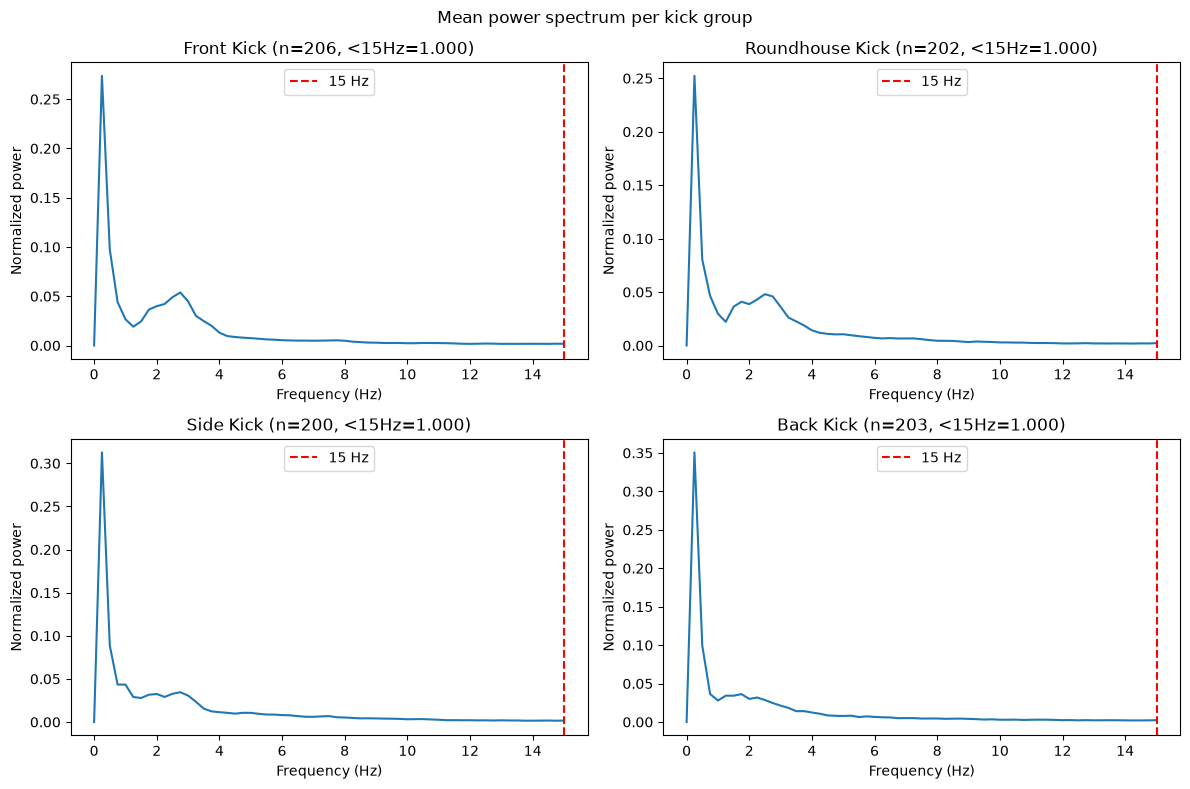

In [3]:
GROUPS = {
    "Front Kick": ["Left Front Kick", "Right Front Kick"],
    "Roundhouse Kick": ["Left Roundhouse Kick", "Right Roundhouse Kick"],
    "Side Kick": ["Left Side Kick", "Right Side Kick"],
    "Back Kick": ["Left Back Kick", "Right Back Kick"],
}


def resultant_magnitude(x):
    return np.sqrt(np.sum(x ** 2, axis=0))


def power_spectrum(sig, fs=FS):
    sig = np.asarray(sig, dtype=np.float64)
    sig = sig - sig.mean()
    n = len(sig)
    f = np.fft.rfftfreq(n, d=1.0 / fs)
    p = np.abs(np.fft.rfft(sig)) ** 2 / n
    return f, p


def energy_below(f, p, cutoff=15.0):
    return float(p[f <= cutoff].sum() / (p.sum() + 1e-12))


def group_spectra(meta, X):
    result = {}
    for gname, actions in GROUPS.items():
        idx = [i for i, a in enumerate(meta["action"]) if a in actions]
        f, _ = power_spectrum(np.zeros(120))
        ps = np.zeros_like(f)
        fracs = []
        for i in idx:
            _, p = power_spectrum(resultant_magnitude(X[i]))
            ps += p / (p.sum() + 1e-12)
            fracs.append(energy_below(f, p))
        result[gname] = (f, ps / len(idx), float(np.mean(fracs)), len(idx))
    return result


spec = group_spectra(meta, X)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (gname, (f, ps, frac, n)) in zip(axes.ravel(), spec.items()):
    ax.plot(f, ps)
    ax.axvline(15.0, color="r", ls="--", label="15 Hz")
    ax.set_title(f"{gname} (n={n}, <15Hz={frac:.3f})")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Normalized power")
    ax.legend()
fig.suptitle("Mean power spectrum per kick group")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "spectral_analysis.png", dpi=150)
plt.show()


## 04 10 折 leave-two-subjects-out 被试级划分

In [4]:
def get_subject_keys(df):
    return sorted(df["subject_key"].unique())


def make_splits(subject_keys, n_folds=N_FOLDS, n_test_subjects=N_TEST_SUBJECTS, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    kicks = sorted(k for k in subject_keys if k.startswith("kick_"))
    punches = sorted(k for k in subject_keys if k.startswith("punch_"))
    half = n_test_subjects // 2
    assert n_test_subjects % 2 == 0, "n_test_subjects 需为偶数"
    assert len(kicks) >= n_folds * half and len(punches) >= n_folds * half, "被试数不足"
    kicks = [str(k) for k in rng.permutation(kicks)]
    punches = [str(k) for k in rng.permutation(punches)]
    splits = []
    for fold in range(n_folds):
        test = kicks[fold * half:(fold + 1) * half] + punches[fold * half:(fold + 1) * half]
        train = [k for k in subject_keys if k not in set(test)]
        splits.append({"fold": fold, "train": train, "test": test})
    return splits


subject_keys = get_subject_keys(df)
splits = make_splits(subject_keys)
print(f"subject_key 总数 {len(subject_keys)}")
for sp in splits:
    print(f"折 {sp['fold']}: test={sp['test']}  train_n={len(sp['train'])}")


subject_key 总数 35
折 0: test=['kick_5', 'punch_8']  train_n=33
折 1: test=['kick_18', 'punch_4']  train_n=33
折 2: test=['kick_4', 'punch_9']  train_n=33
折 3: test=['kick_16', 'punch_13']  train_n=33
折 4: test=['kick_20', 'punch_12']  train_n=33
折 5: test=['kick_19', 'punch_0']  train_n=33
折 6: test=['kick_15', 'punch_3']  train_n=33
折 7: test=['kick_9', 'punch_2']  train_n=33
折 8: test=['kick_12', 'punch_7']  train_n=33
折 9: test=['kick_1', 'punch_10']  train_n=33


## 05 手工特征提取（15 通道 × 12 特征 = 180）

In [5]:
FEATURE_NAMES = ["mean", "std", "var", "min", "max", "skew", "kurtosis",
                 "rms", "zcr", "fft_domfreq", "fft_energy", "fft_entropy"]


def extract_features(X):
    n, C, T = X.shape
    feat = np.zeros((n, C, len(FEATURE_NAMES)), dtype=np.float64)
    feat[:, :, 0] = X.mean(axis=2)
    feat[:, :, 1] = X.std(axis=2)
    feat[:, :, 2] = X.var(axis=2)
    feat[:, :, 3] = X.min(axis=2)
    feat[:, :, 4] = X.max(axis=2)
    feat[:, :, 7] = np.sqrt(np.mean(X ** 2, axis=2))
    feat[:, :, 8] = np.sum((X[:, :, :-1] >= 0) != (X[:, :, 1:] >= 0), axis=2) / T
    mean = feat[:, :, 0:1]
    std = feat[:, :, 1:2]
    with np.errstate(divide="ignore", invalid="ignore"):
        z = np.where(std > 0, (X - mean) / np.where(std > 0, std, 1.0), 0.0)
    feat[:, :, 5] = np.mean(z ** 3, axis=2)
    feat[:, :, 6] = np.mean(z ** 4, axis=2) - 3.0
    spec = np.abs(np.fft.rfft(X, axis=2)) ** 2
    freqs = np.fft.rfftfreq(T, d=1.0 / FS)
    feat[:, :, 9] = freqs[np.argmax(spec, axis=2)]
    feat[:, :, 10] = spec.sum(axis=2)
    ps = spec / (spec.sum(axis=2, keepdims=True) + 1e-12)
    feat[:, :, 11] = -np.sum(ps * np.log2(ps + 1e-12), axis=2)
    return feat.reshape(n, C * len(FEATURE_NAMES))


F = extract_features(X)
print(f"特征矩阵 {F.shape}（样本 × 特征）")


特征矩阵 (1522, 180)（样本 × 特征）


## 06 机器学习基线：SVM / 随机森林 / 决策树

In [12]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# ===================== 全局变量（请自行修改为你的真实配置） =====================
import pathlib
RESULTS_DIR = pathlib.Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)
GRID_CV = 3
CLASSES = ["动作1","动作2","动作3"] # 替换为你的动作类别

# ===================== 超参搜索空间（IMU人体动作识别常用范围） =====================
# SVM RBF核
SVM_PARAM_GRID = {
    "kernel": ["rbf"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1]
}
# 随机森林
RF_PARAM_GRID = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 8, 16, 32],
    "min_samples_split": [2, 5]
}
# 决策树
DT_PARAM_GRID = {
    "max_depth": [None, 4, 8, 16],
    "min_samples_split": [2, 5]
}

def build_model(model_type, class_weight=None):
    kw = dict(random_state=0)
    if class_weight:
        kw["class_weight"] = class_weight
    if model_type == "svm":
        return SVC(**kw)
    if model_type == "rf":
        return RandomForestClassifier(**kw)
    if model_type == "dt":
        return DecisionTreeClassifier(**kw)
    raise ValueError(model_type)

def run_cv(model_type, param_grid, F, y, meta, splits, class_weight=None, gs_scoring="f1_macro"):
    fold_rows = []          # 每折整体指标
    fold_perclass_list = [] # 每折每个类别的precision/recall/f1
    fold_best_params = []   # 每折网格搜索最优参数
    yt_all, yp_all = [], []
    for sp in splits:
        tr = meta["subject_key"].isin(sp["train"]).to_numpy()
        te = meta["subject_key"].isin(sp["test"]).to_numpy()
        Xtr, Xte = F[tr], F[te]
        ytr, yte = y[tr], y[te]
        # 标准化：仅训练集拟合
        scaler = StandardScaler().fit(Xtr)
        Xtr = scaler.transform(Xtr)
        Xte = scaler.transform(Xte)

        model = build_model(model_type, class_weight=class_weight)
        gs = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=GRID_CV,
            scoring=gs_scoring,
            n_jobs=-1,
            refit=True
        )
        gs.fit(Xtr, ytr)
        pred = gs.predict(Xte)

        # 本折整体指标
        acc = accuracy_score(yte, pred)
        macro_f1 = f1_score(yte, pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(yte, pred, average="weighted", zero_division=0)
        w_prec = precision_score(yte, pred, average="weighted", zero_division=0)
        w_rec = recall_score(yte, pred, average="weighted", zero_division=0)

        fold_rows.append({
            "fold": sp["fold"],
            "accuracy": acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "weighted_precision": w_prec,
            "weighted_recall": w_rec,
        })
        fold_best_params.append({"fold": sp["fold"], "best_params": gs.best_params_})

        # 本折每一类 precision / recall / f1
        rep_fold = classification_report(
            yte, pred,
            labels=range(len(CLASSES)),
            target_names=CLASSES,
            output_dict=True,
            zero_division=0
        )
        for cls_name in CLASSES:
            fold_perclass_list.append({
                "fold": sp["fold"],
                "class": cls_name,
                "precision": rep_fold[cls_name]["precision"],
                "recall": rep_fold[cls_name]["recall"],
                "f1": rep_fold[cls_name]["f1-score"]
            })
        yt_all.append(yte)
        yp_all.append(pred)

    # 全部折合并后的全局指标（用于画混淆矩阵，不做为主结果）
    yt = np.concatenate(yt_all)
    yp = np.concatenate(yp_all)
    agg = {
        "accuracy": accuracy_score(yt, yp),
        "macro_f1": f1_score(yt, yp, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt, yp, average="weighted", zero_division=0),
        "weighted_precision": precision_score(yt, yp, average="weighted", zero_division=0),
        "weighted_recall": recall_score(yt, yp, average="weighted", zero_division=0),
    }
    cm = confusion_matrix(yt, yp, labels=range(len(CLASSES)))
    rep_global = classification_report(
        yt, yp, labels=range(len(CLASSES)),
        target_names=CLASSES, output_dict=True, zero_division=0
    )
    df_global_perclass = pd.DataFrame(rep_global).T
    df_folds = pd.DataFrame(fold_rows)
    df_fold_perclass = pd.DataFrame(fold_perclass_list)
    df_bestparams = pd.DataFrame(fold_best_params)
    return agg, cm, df_folds, df_global_perclass, df_fold_perclass, df_bestparams

# ===================== 主循环 =====================
ml_results = {}
model_configs = [
    ("svm", SVM_PARAM_GRID),
    ("rf", RF_PARAM_GRID),
    ("dt", DT_PARAM_GRID)
]
for m_name, grid in model_configs:
    agg, cm, folds_df, pc_global_df, pc_fold_df, bestparam_df = run_cv(
        model_type=m_name,
        param_grid=grid,
        F=F,
        y=y,
        meta=meta,
        splits=splits,
        class_weight=None,
        gs_scoring="f1_macro"
    )
    ml_results[m_name] = agg
    np.save(RESULTS_DIR / f"ml_{m_name}_confusion.npy", cm)
    folds_df.to_csv(RESULTS_DIR / f"ml_{m_name}_folds.csv", index=False)
    pc_global_df.to_csv(RESULTS_DIR / f"ml_{m_name}_per_class_global.csv", index=True)
    pc_fold_df.to_csv(RESULTS_DIR / f"ml_{m_name}_per_class_folds.csv", index=False)
    bestparam_df.to_csv(RESULTS_DIR / f"ml_{m_name}_best_params.csv", index=False)

# ========== 全部模型汇总：k折指标 mean ± std（论文主表，推荐） ==========
summary_mean = []
for m_name in ["svm","rf","dt"]:
    df_fold = pd.read_csv(RESULTS_DIR / f"ml_{m_name}_folds.csv")
    stat = df_fold[["accuracy","weighted_precision","weighted_recall","weighted_f1","macro_f1"]].agg(["mean","std"])
    summary_mean.append({
        "model": m_name,
        "accuracy_mean": stat.loc["mean","accuracy"],
        "accuracy_std": stat.loc["std","accuracy"],
        "wp_mean": stat.loc["mean","weighted_precision"],
        "wp_std": stat.loc["std","weighted_precision"],
        "wr_mean": stat.loc["mean","weighted_recall"],
        "wr_std": stat.loc["std","weighted_recall"],
        "wf1_mean": stat.loc["mean","weighted_f1"],
        "wf1_std": stat.loc["std","weighted_f1"],
        "mf1_mean": stat.loc["mean","macro_f1"],
        "mf1_std": stat.loc["std","macro_f1"],
    })
summary_df_mean = pd.DataFrame(summary_mean)
summary_df_mean.to_csv(RESULTS_DIR / "ml_all_model_summary_mean_std.csv", index=False)
print("\n==== 所有模型汇总（k折交叉验证 mean ± std） ====")
print(summary_df_mean.round(4))



==== 所有模型汇总（k折交叉验证 mean ± std） ====
  model  accuracy_mean  accuracy_std  wp_mean  wp_std  wr_mean  wr_std  \
0   svm         0.8709        0.0803   0.8835  0.0710   0.8709  0.0803   
1    rf         0.8365        0.0974   0.8378  0.1159   0.8365  0.0974   
2    dt         0.4988        0.2007   0.5021  0.2194   0.4988  0.2007   

   wf1_mean  wf1_std  mf1_mean  mf1_std  
0    0.8580   0.0858    0.8457   0.1042  
1    0.8125   0.1178    0.8027   0.1299  
2    0.4598   0.2106    0.4607   0.1991  


## 07 深度学习基线：ResNet / GRU / Transformer

resnet: precision=0.8942 recall=0.8903 f1=0.8852 weighted_f1=0.8899 accuracy=0.8903
gru: precision=0.6278 recall=0.6229 f1=0.6241 weighted_f1=0.6182 accuracy=0.6229
transformer: precision=0.7510 recall=0.7497 f1=0.7472 weighted_f1=0.7474 accuracy=0.7497

==== DL模型汇总（k折交叉验证 mean ± std） ====
         model  accuracy_mean  accuracy_std  wp_mean  wp_std  wr_mean  wr_std  \
0       resnet         0.8887        0.0700   0.9121  0.0673   0.8887  0.0700   
1          gru         0.6199        0.1681   0.5996  0.1797   0.6199  0.1681   
2  transformer         0.7429        0.0945   0.7644  0.0946   0.7429  0.0945   

   wf1_mean  wf1_std  mf1_mean  mf1_std  
0    0.8777   0.0795    0.8679   0.0872  
1    0.5704   0.1800    0.5730   0.1644  
2    0.7061   0.1063    0.6959   0.1121  


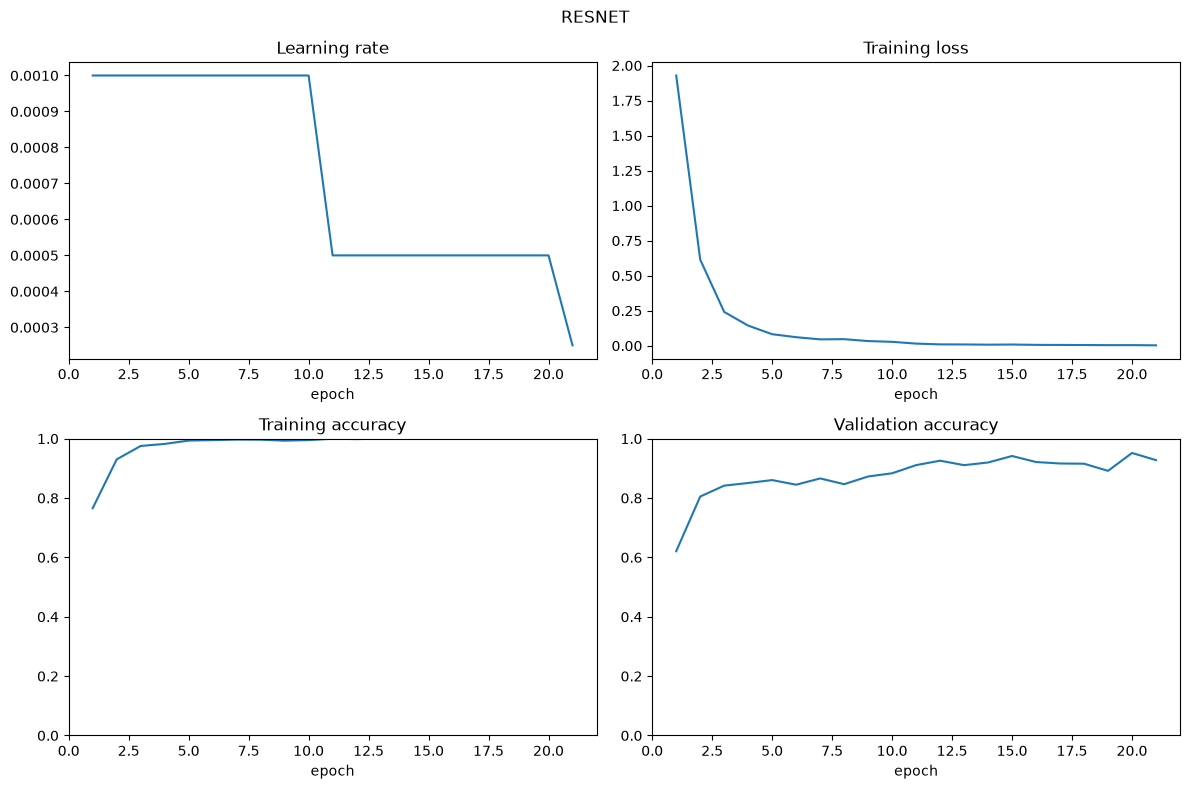

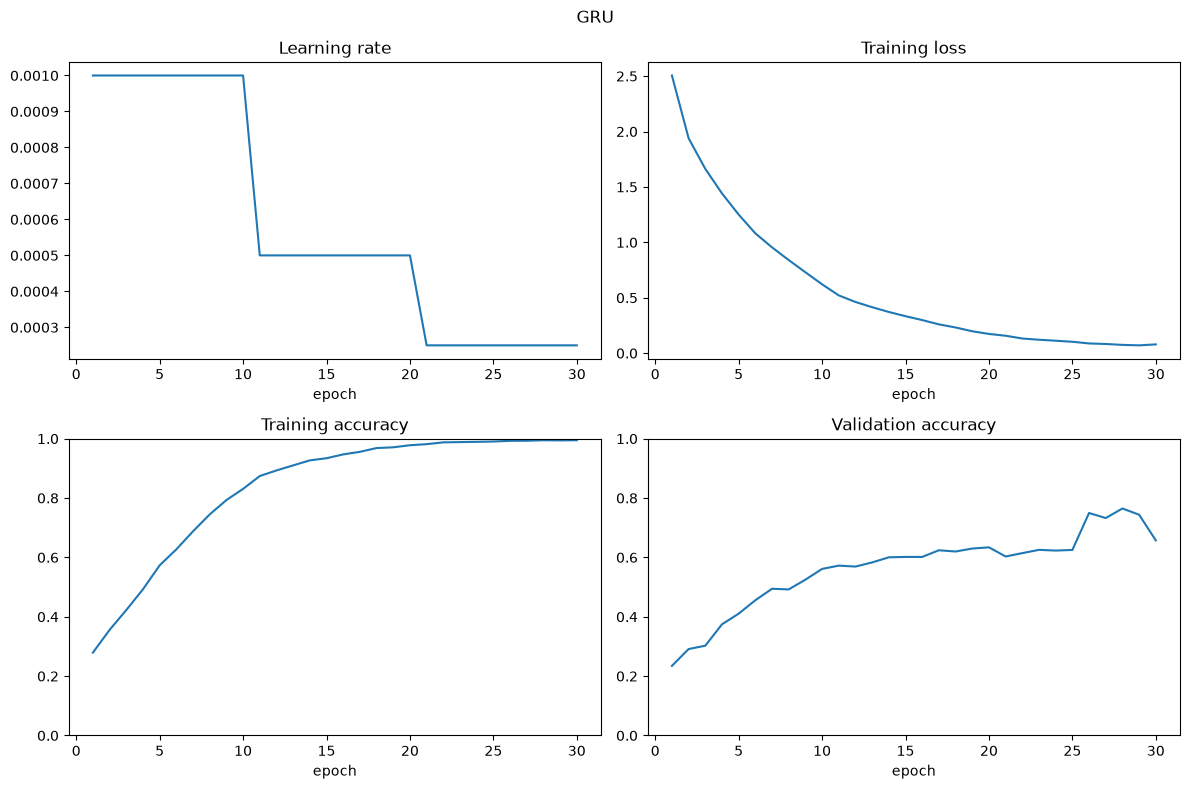

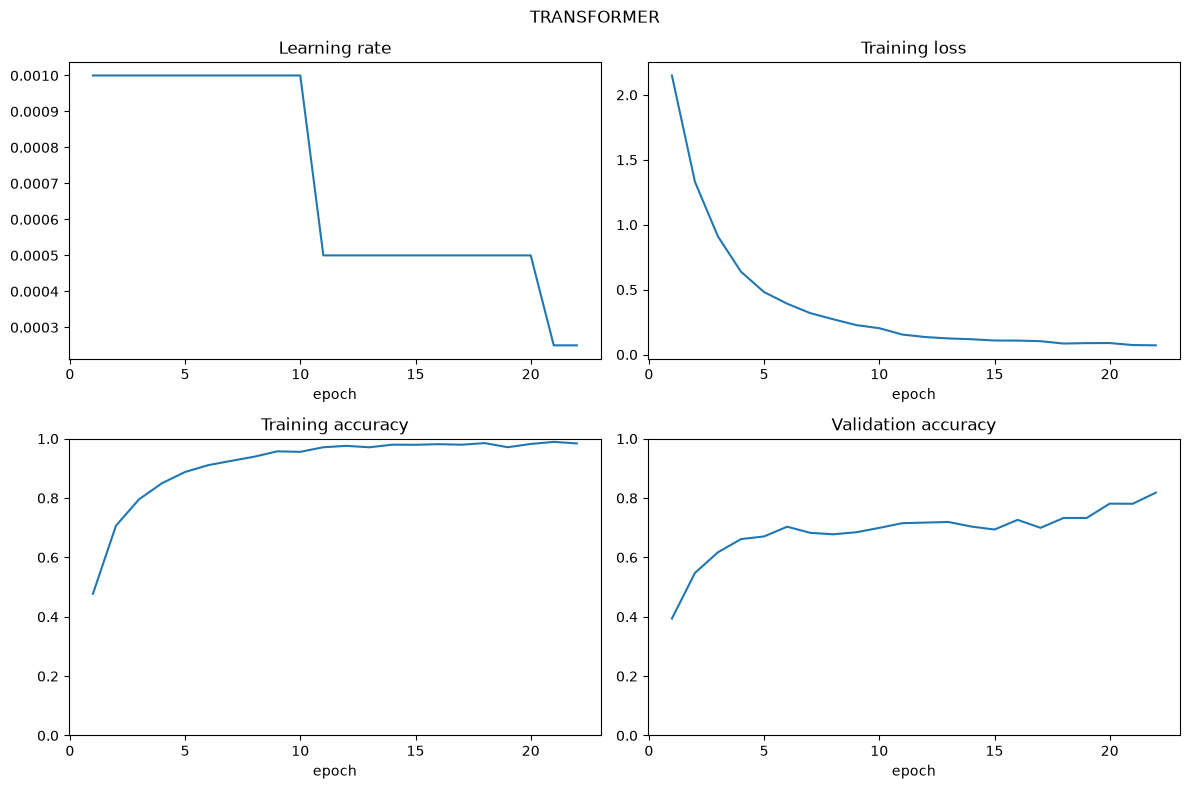

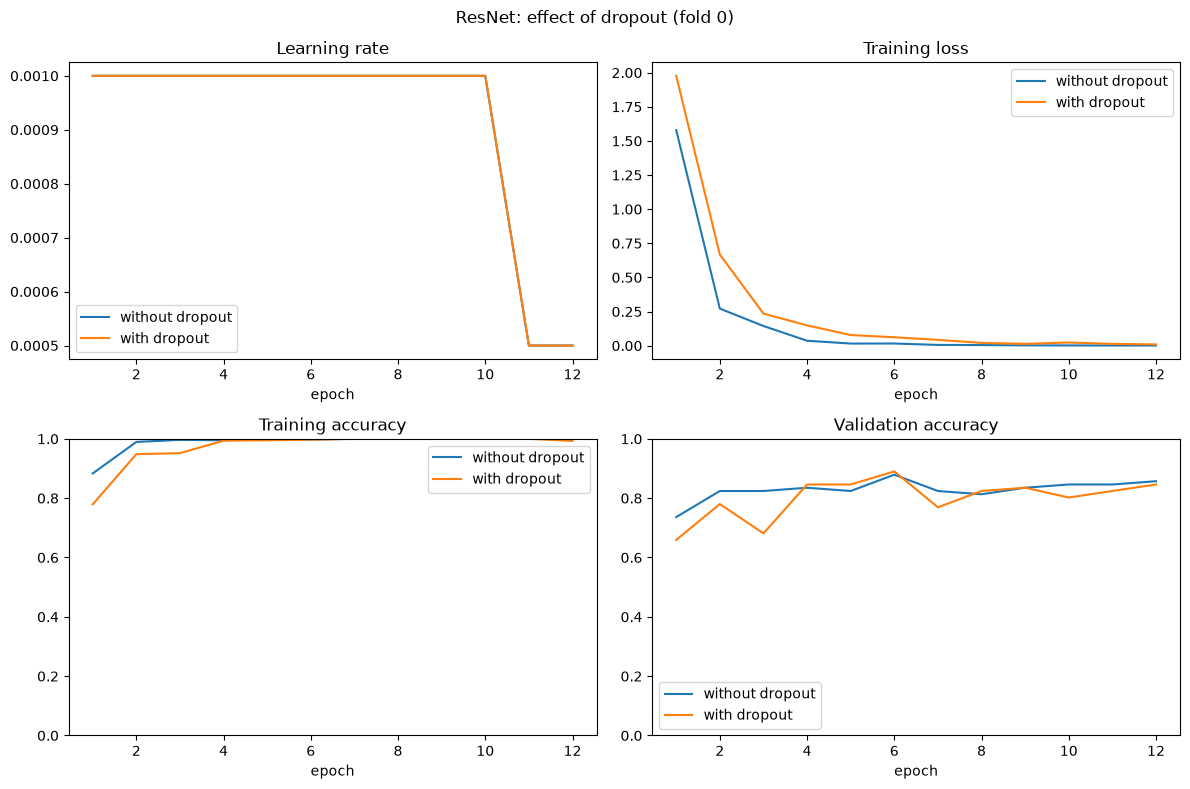

In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from pathlib import Path
import random

# ===================== 【全局超参数】 =====================
CLASSES = list(range(16))
DL_HIDDEN = 64
DL_EPOCHS = 30
DL_BATCH_SIZE = 32
DL_LR = 1e-3
DL_WEIGHT_DECAY = 1e-4
DL_LR_STEP = 10
DL_LR_GAMMA = 0.5
DL_DROPOUT = 0.3
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)

# ===================== 固定随机种子（绝对可复现核心） =====================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # torch.use_deterministic_algorithms(True) # 可选，报错就注释掉

# ===================== 模型定义 =====================
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, stride, 1)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, 1, 1)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride), nn.BatchNorm1d(out_ch))
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.relu = nn.ReLU()
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)

class ResNet1D(nn.Module):
    def __init__(self, in_channels=15, n_classes=16, hidden=64, dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, hidden, 7, 2, 3),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.MaxPool1d(3, 2, 1),
        )
        self.block1 = ResidualBlock(hidden, hidden, dropout=dropout)
        self.block2 = ResidualBlock(hidden, hidden * 2, stride=2, dropout=dropout)
        self.block3 = ResidualBlock(hidden * 2, hidden * 2, dropout=dropout)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Linear(hidden, n_classes))
    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

class GRUModel(nn.Module):
    def __init__(self, in_channels=15, n_classes=16, hidden=64, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(in_channels, hidden, num_layers=2, batch_first=True,
                          dropout=dropout, bidirectional=True)
        self.head = nn.Linear(hidden * 2, n_classes)
    def forward(self, x):
        out, _ = self.gru(x.transpose(1, 2))
        return self.head(out[:, -1])

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.3, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TransformerModel(nn.Module):
    def __init__(self, in_channels=15, n_classes=16, hidden=64, dropout=0.3, nhead=4, n_layers=2):
        super().__init__()
        self.proj = nn.Linear(in_channels, hidden)
        self.pos = PositionalEncoding(hidden, dropout)
        self.enc = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(hidden, nhead, hidden * 4, dropout, batch_first=True),
            num_layers=n_layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(hidden, n_classes)
    def forward(self, x):
        x = self.proj(x.transpose(1, 2))
        x = self.pos(x)
        x = self.enc(x)
        x = self.pool(x.transpose(1, 2)).flatten(1)
        return self.head(x)

def build_dl_model(name, n_classes=len(CLASSES), hidden=DL_HIDDEN, dropout=DL_DROPOUT):
    if name == "resnet":
        return ResNet1D(in_channels=15, n_classes=n_classes, hidden=hidden, dropout=dropout)
    if name == "gru":
        return GRUModel(in_channels=15, n_classes=n_classes, hidden=hidden, dropout=dropout)
    if name == "transformer":
        return TransformerModel(in_channels=15, n_classes=n_classes, hidden=hidden, dropout=dropout)
    raise ValueError(name)

def standardize(Xtr, Xte):
    mean = Xtr.mean(axis=(0, 2), keepdims=True)
    std = Xtr.std(axis=(0, 2), keepdims=True)
    return (Xtr - mean) / (std + 1e-8), (Xte - mean) / (std + 1e-8)

def predict(model, X, batch_size=DL_BATCH_SIZE, device="cpu"):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.as_tensor(X[i:i + batch_size], dtype=torch.float32, device=device)
            logits = model(xb)
            preds.append(logits.argmax(1))
        pred_tensor = torch.cat(preds)
    return pred_tensor.cpu().numpy()

def dl_metrics(y_true, y_pred):
    return {
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

def train_fold(model, Xtr, ytr, Xte, yte, epochs=DL_EPOCHS, batch_size=DL_BATCH_SIZE,
               lr=DL_LR, weight_decay=DL_WEIGHT_DECAY, device="cpu", patience=6):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=DL_LR_STEP, gamma=DL_LR_GAMMA)
    lossf = nn.CrossEntropyLoss()
    n = len(ytr)

    Xtr_t = torch.as_tensor(Xtr, dtype=torch.float32, device=device)
    ytr_t = torch.as_tensor(ytr, dtype=torch.long, device=device)
    Xte_t = torch.as_tensor(Xte, dtype=torch.float32, device=device)
    yte_t = torch.as_tensor(yte, dtype=torch.long, device=device)

    history = []
    best_val_acc = 0.0
    wait = 0
    best_weights = None

    for _ in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        losses = []
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb = Xtr_t[idx]
            yb = ytr_t[idx]
            opt.zero_grad()
            logits = model(xb)
            loss = lossf(logits, yb)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            tr_pred = model(Xtr_t).argmax(1)
            val_pred = model(Xte_t).argmax(1)
            train_acc = (tr_pred == ytr_t).float().mean().item()
            val_acc = (val_pred == yte_t).float().mean().item()

        history.append({
            "epoch": len(history) + 1,
            "lr": sched.get_last_lr()[0],
            "train_loss": float(np.mean(losses)),
            "train_acc": train_acc,
            "val_acc": val_acc,
        })
        sched.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            wait = 0
            best_weights = model.state_dict()
        else:
            wait += 1
            if wait >= patience:
                break
    if best_weights is not None:
        model.load_state_dict(best_weights)
    pred = predict(model, Xte, batch_size, device)
    return history, pred

def run_dl(model_name, X, y, meta, splits, epochs=DL_EPOCHS, batch_size=DL_BATCH_SIZE,
           lr=DL_LR, weight_decay=DL_WEIGHT_DECAY, dropout=DL_DROPOUT, hidden=DL_HIDDEN,
           device="cpu", seed=42):
    set_seed(seed)
    fold_rows, yt_all, yp_all, histories = [], [], [], []
    for sp in splits:
        tr = meta["subject_key"].isin(sp["train"]).to_numpy()
        te = meta["subject_key"].isin(sp["test"]).to_numpy()
        Xtr, Xte = standardize(X[tr], X[te])
        history, pred = train_fold(build_dl_model(model_name, hidden=hidden, dropout=dropout),
                                   Xtr, y[tr], Xte, y[te], epochs=epochs, batch_size=batch_size,
                                   lr=lr, weight_decay=weight_decay, device=device)
        fold_rows.append({"fold": sp["fold"], **dl_metrics(y[te], pred)})
        yt_all.append(y[te])
        yp_all.append(pred)
        hdf = pd.DataFrame(history)
        hdf["fold"] = sp["fold"]
        histories.append(hdf)
    yt = np.concatenate(yt_all)
    yp = np.concatenate(yp_all)
    agg = dl_metrics(yt, yp)
    cm = confusion_matrix(yt, yp, labels=range(len(CLASSES)))
    return agg, cm, pd.DataFrame(fold_rows), pd.concat(histories, ignore_index=True)

# ===================== 主训练 =====================
device = "cuda" if torch.cuda.is_available() else "cpu"
dl_results = {}
for m in ["resnet", "gru", "transformer"]:
    agg, cm, folds, hist = run_dl(m, X, y, meta, splits, device=device)
    dl_results[m] = agg
    np.save(RESULTS_DIR / f"dl_{m}_confusion.npy", cm)
    folds.to_csv(RESULTS_DIR / f"dl_{m}_folds.csv", index=False)
    hist.to_csv(RESULTS_DIR / f"dl_{m}_history.csv", index=False)
    avg = hist.groupby("epoch")[["lr", "train_loss", "train_acc", "val_acc"]].mean().reset_index()
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].plot(avg["epoch"], avg["lr"]); axes[0, 0].set_xlabel("epoch"); axes[0, 0].set_title("Learning rate")
    axes[0, 1].plot(avg["epoch"], avg["train_loss"]); axes[0, 1].set_xlabel("epoch"); axes[0, 1].set_title("Training loss")
    axes[1, 0].plot(avg["epoch"], avg["train_acc"]); axes[1, 0].set_xlabel("epoch"); axes[1, 0].set_title("Training accuracy"); axes[1, 0].set_ylim(0, 1)
    axes[1, 1].plot(avg["epoch"], avg["val_acc"]); axes[1, 1].set_xlabel("epoch"); axes[1, 1].set_title("Validation accuracy"); axes[1, 1].set_ylim(0, 1)
    fig.suptitle(m.upper()); fig.tight_layout()
    fig.savefig(RESULTS_DIR / f"dl_{m}_curves.png", dpi=150)
    # plt.show() # 正式跑实验建议注释，节省时间
    print(f"{m}: precision={agg['precision']:.4f} recall={agg['recall']:.4f} f1={agg['f1']:.4f} "
          f"weighted_f1={agg['weighted_f1']:.4f} accuracy={agg['accuracy']:.4f}")

# dropout消融实验（仅fold0，定性分析）
sp0 = splits[0]
tr0 = meta["subject_key"].isin(sp0["train"]).to_numpy()
te0 = meta["subject_key"].isin(sp0["test"]).to_numpy()
Xtr0, Xte0 = standardize(X[tr0], X[te0])
drop_hists = {}
for lbl, drop in [("without dropout", 0.0), ("with dropout", DL_DROPOUT)]:
    set_seed(42)
    h, _ = train_fold(build_dl_model("resnet", dropout=drop), Xtr0, y[tr0], Xte0, y[te0], device=device)
    drop_hists[lbl] = pd.DataFrame(h)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for lbl, h in drop_hists.items():
    axes[0, 0].plot(h["epoch"], h["lr"], label=lbl)
    axes[0, 1].plot(h["epoch"], h["train_loss"], label=lbl)
    axes[1, 0].plot(h["epoch"], h["train_acc"], label=lbl)
    axes[1, 1].plot(h["epoch"], h["val_acc"], label=lbl)
axes[0, 0].set_xlabel("epoch"); axes[0, 0].set_title("Learning rate")
axes[0, 1].set_xlabel("epoch"); axes[0, 1].set_title("Training loss")
axes[1, 0].set_xlabel("epoch"); axes[1, 0].set_title("Training accuracy"); axes[1, 0].set_ylim(0, 1)
axes[1, 1].set_xlabel("epoch"); axes[1, 1].set_title("Validation accuracy"); axes[1, 1].set_ylim(0, 1)
for ax in axes.ravel():
    ax.legend()
fig.suptitle("ResNet: effect of dropout (fold 0)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "dl_dropout_comparison.png", dpi=150)
# plt.show()

# ========== DL模型汇总：k折交叉验证 mean ± std（论文主表） ==========
summary_dl = []
for m_name in ["resnet","gru","transformer"]:
    df_fold = pd.read_csv(RESULTS_DIR / f"dl_{m_name}_folds.csv")
    stat = df_fold[["precision","recall","f1","weighted_f1","accuracy"]].agg(["mean","std"])
    summary_dl.append({
        "model": m_name,
        "accuracy_mean": stat.loc["mean","accuracy"],
        "accuracy_std": stat.loc["std","accuracy"],
        "wp_mean": stat.loc["mean","precision"],
        "wp_std": stat.loc["std","precision"],
        "wr_mean": stat.loc["mean","recall"],
        "wr_std": stat.loc["std","recall"],
        "wf1_mean": stat.loc["mean","weighted_f1"],
        "wf1_std": stat.loc["std","weighted_f1"],
        "mf1_mean": stat.loc["mean","f1"],
        "mf1_std": stat.loc["std","f1"],
    })
summary_df_dl = pd.DataFrame(summary_dl)
summary_df_dl.to_csv(RESULTS_DIR / "dl_all_model_summary_mean_std.csv", index=False)
print("\n==== DL模型汇总（k折交叉验证 mean ± std） ====")
print(summary_df_dl.round(4))


正在训练：without dropout ...
正在训练：with dropout ...

ResNet Dropout Ablation Study · Quantitative Results (Fold 0)
                 precision  recall  macro_f1  weighted_f1  accuracy
without dropout     0.8628  0.8242    0.7952       0.7979    0.8242
with dropout        0.9375  0.9121    0.8981       0.9102    0.9121

Performance Gain from Dropout
precision      0.0747
recall         0.0879
macro_f1       0.1029
weighted_f1    0.1123
accuracy       0.0879
dtype: float64

所有结果已保存至：E:\yanjiusheng\datas\datas\results


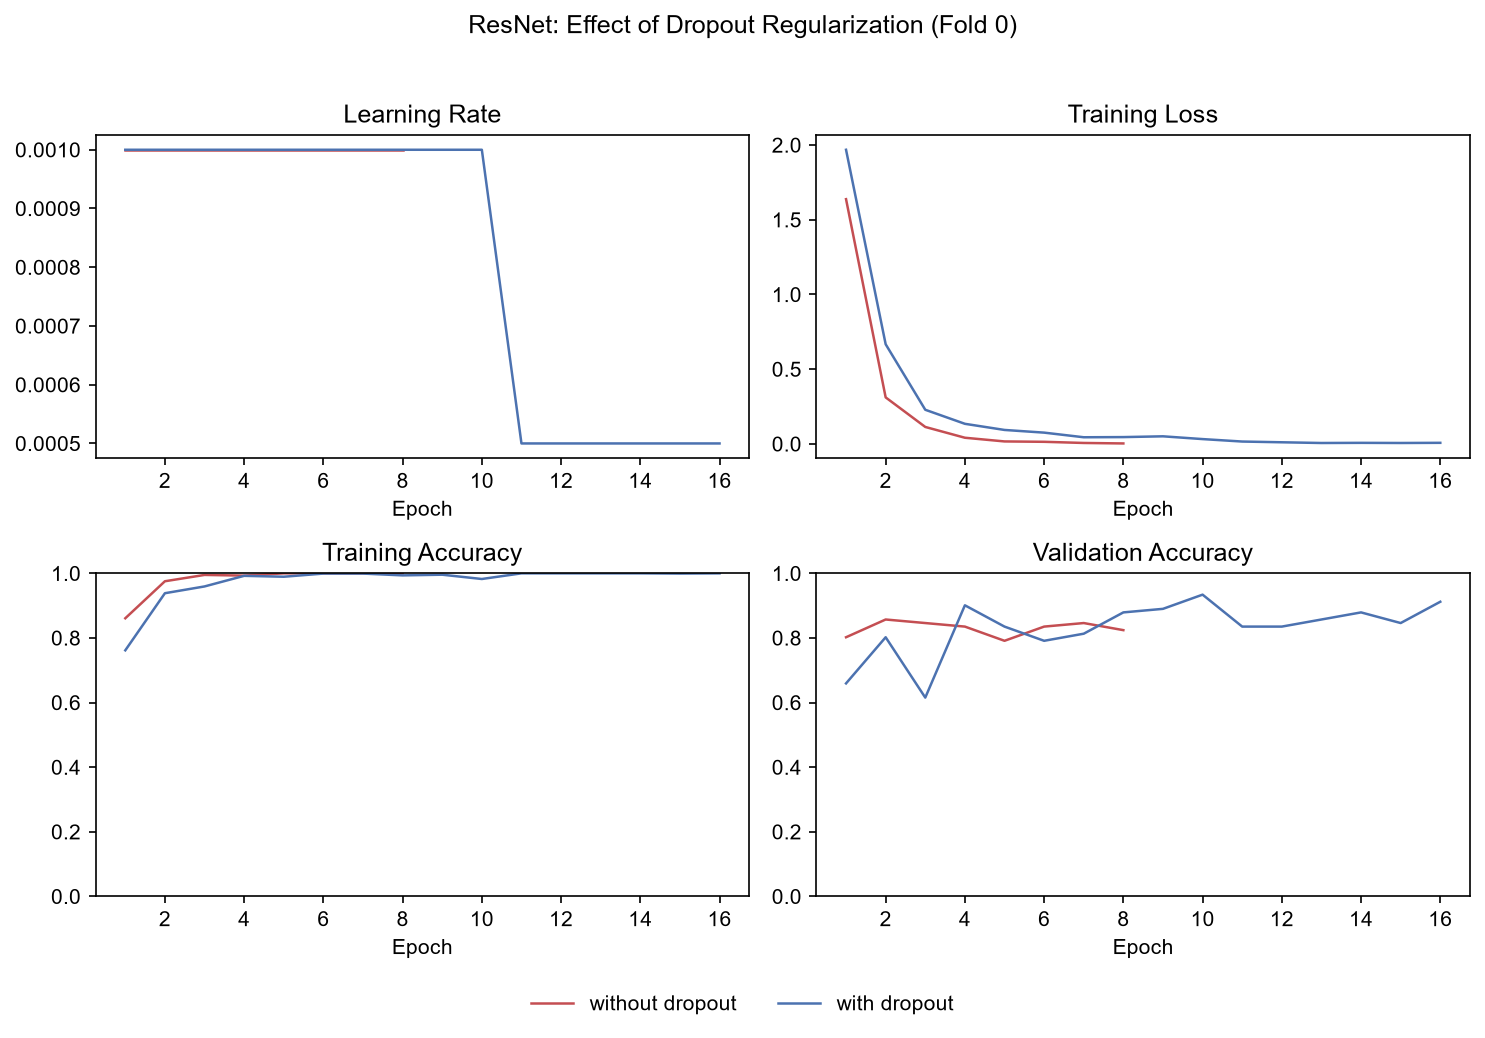

In [38]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from pathlib import Path
import random

# ===================== 超参数：与原主实验完全一致 =====================
DL_HIDDEN = 64
DL_EPOCHS = 30
DL_BATCH_SIZE = 32
DL_LR = 1e-3
DL_WEIGHT_DECAY = 1e-4
DL_LR_STEP = 10
DL_LR_GAMMA = 0.5
DL_DROPOUT = 0.3
NUM_CLASSES = 16
IN_CHANNELS = 15

RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ===================== 固定种子 =====================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ===================== 模型定义 =====================
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, stride, 1)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, 1, 1)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, stride), nn.BatchNorm1d(out_ch))
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.relu = nn.ReLU()
    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)

class ResNet1D(nn.Module):
    def __init__(self, in_channels=15, n_classes=16, hidden=64, dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, hidden, 7, 2, 3),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.MaxPool1d(3, 2, 1),
        )
        self.block1 = ResidualBlock(hidden, hidden, dropout=dropout)
        self.block2 = ResidualBlock(hidden, hidden * 2, stride=2, dropout=dropout)
        self.block3 = ResidualBlock(hidden * 2, hidden * 2, dropout=dropout)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Linear(hidden, n_classes))
    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).flatten(1)
        return self.head(x)

# ===================== 工具函数 =====================
def standardize(Xtr, Xte):
    mean = Xtr.mean(axis=(0, 2), keepdims=True)
    std = Xtr.std(axis=(0, 2), keepdims=True)
    return (Xtr - mean) / (std + 1e-8), (Xte - mean) / (std + 1e-8)

def predict(model, X, batch_size=DL_BATCH_SIZE, device="cpu"):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.as_tensor(X[i:i + batch_size], dtype=torch.float32, device=device)
            logits = model(xb)
            preds.append(logits.argmax(1))
        pred_tensor = torch.cat(preds)
    return pred_tensor.cpu().numpy()

def dl_metrics(y_true, y_pred):
    return {
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

# ===================== 训练函数：与原实验逻辑完全一致 =====================
def train_fold(model, Xtr, ytr, Xte, yte, epochs=DL_EPOCHS, batch_size=DL_BATCH_SIZE,
              lr=DL_LR, weight_decay=DL_WEIGHT_DECAY, device="cpu", patience=6):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=DL_LR_STEP, gamma=DL_LR_GAMMA)
    lossf = nn.CrossEntropyLoss()
    n = len(ytr)

    Xtr_t = torch.as_tensor(Xtr, dtype=torch.float32, device=device)
    ytr_t = torch.as_tensor(ytr, dtype=torch.long, device=device)
    Xte_t = torch.as_tensor(Xte, dtype=torch.float32, device=device)
    yte_t = torch.as_tensor(yte, dtype=torch.long, device=device)

    history = []
    best_val_acc = 0.0
    wait = 0
    best_weights = None

    for _ in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        losses = []
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb = Xtr_t[idx]
            yb = ytr_t[idx]
            opt.zero_grad()
            logits = model(xb)
            loss = lossf(logits, yb)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            tr_pred = model(Xtr_t).argmax(1)
            val_pred = model(Xte_t).argmax(1)
            train_acc = (tr_pred == ytr_t).float().mean().item()
            val_acc = (val_pred == yte_t).float().mean().item()

        history.append({
            "epoch": len(history) + 1,
            "lr": sched.get_last_lr()[0],
            "train_loss": float(np.mean(losses)),
            "train_acc": train_acc,
            "val_acc": val_acc,
        })
        sched.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            wait = 0
            best_weights = model.state_dict()
        else:
            wait += 1
            if wait >= patience:
                break

    if best_weights is not None:
        model.load_state_dict(best_weights)
    pred = predict(model, Xte, batch_size, device)
    return history, pred

# ===================== 主程序：Dropout 消融实验 =====================
if __name__ == "__main__":
    sp0 = splits[0]
    tr0 = meta["subject_key"].isin(sp0["train"]).to_numpy()
    te0 = meta["subject_key"].isin(sp0["test"]).to_numpy()
    Xtr0, Xte0 = standardize(X[tr0], X[te0])
    ytr0, yte0 = y[tr0], y[te0]

    ablation_groups = [
        ("without dropout", 0.0),
        ("with dropout", DL_DROPOUT),
    ]

    history_dict = {}
    metrics_dict = {}

    for label, dropout_rate in ablation_groups:
        print(f"正在训练：{label} ...")
        set_seed(42)
        model = ResNet1D(
            in_channels=IN_CHANNELS,
            n_classes=NUM_CLASSES,
            hidden=DL_HIDDEN,
            dropout=dropout_rate
        )
        hist, pred = train_fold(model, Xtr0, ytr0, Xte0, yte0, device=device)
        history_dict[label] = pd.DataFrame(hist)
        metrics_dict[label] = dl_metrics(yte0, pred)

    # ========== 1. 定量结果输出 ==========
    print("\n" + "=" * 65)
    print("ResNet Dropout Ablation Study · Quantitative Results (Fold 0)")
    print("=" * 65)
    metrics_df = pd.DataFrame(metrics_dict).T.round(4)
    print(metrics_df)
    metrics_df.to_csv(RESULTS_DIR / "resnet_dropout_ablation_metrics.csv")

    gain = metrics_df.loc["with dropout"] - metrics_df.loc["without dropout"]
    print("\n" + "=" * 65)
    print("Performance Gain from Dropout")
    print("=" * 65)
    print(gain.round(4))

    # ========== 2. 优化版训练曲线对比图 ==========
    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": 10,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
    })

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), dpi=150)
    colors = ["#c44e52", "#4c72b0"]  # 学术经典配色：红-无dropout，蓝-有dropout

    # 绘制四条子图曲线
    for (label, hist_df), color in zip(history_dict.items(), colors):
        axes[0, 0].plot(hist_df["epoch"], hist_df["lr"], color=color, label=label)
        axes[0, 1].plot(hist_df["epoch"], hist_df["train_loss"], color=color, label=label)
        axes[1, 0].plot(hist_df["epoch"], hist_df["train_acc"], color=color, label=label)
        axes[1, 1].plot(hist_df["epoch"], hist_df["val_acc"], color=color, label=label)

    # 子图标签与标题
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_title("Learning Rate")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_title("Training Loss")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_title("Training Accuracy")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_title("Validation Accuracy")
    axes[1, 1].set_ylim(0, 1)

    # 【核心优化】全局仅1组图例，放在底部居中，无外框
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 0.01),
        fontsize=10
    )

    fig.suptitle("ResNet: Effect of Dropout Regularization (Fold 0)", y=0.98, fontsize=12)
    # 调整布局：给底部图例预留空间，子图间距均匀
    fig.tight_layout(rect=[0, 0.06, 1, 0.96])

    fig.savefig(
        RESULTS_DIR / "resnet_dropout_ablation_curves.png",
        dpi=150,
        bbox_inches="tight",
        facecolor="white"
    )
    print(f"\n所有结果已保存至：{RESULTS_DIR.resolve()}")


## 08 传感器消融：不同通道子集下的 SVM 性能

In [16]:
ABLATION_SETS = {
    "仅双腕(6)": SENSOR_GROUPS["wrists"],
    "仅双踝(6)": SENSOR_GROUPS["ankles"],
    "仅后腰(3)": SENSOR_GROUPS["waist"],
    "上肢(双腕+后腰,9)": SENSOR_GROUPS["wrists"] + SENSOR_GROUPS["waist"],
    "下肢(双踝+后腰,9)": SENSOR_GROUPS["ankles"] + SENSOR_GROUPS["waist"],
    "全部(15)": CHANNELS,
}
rows = []
for name, chans in ABLATION_SETS.items():
    idx = [CHANNELS.index(c) for c in chans]
    Fsub = extract_features(X[:, idx, :])
    # 6个返回值全部接收
    agg, cm, df_folds, df_global_perclass, df_fold_perclass, df_bestparams = run_cv("svm", SVM_PARAM_GRID, Fsub, y, meta, splits)
    rows.append({
        "sensor_set": name,
        "n_channels": len(chans),
        "n_features": Fsub.shape[1],
        "macro_f1": round(agg["macro_f1"], 4),
        "weighted_f1": round(agg["weighted_f1"], 4),
        "accuracy": round(agg["accuracy"], 4),
    })
ablation = pd.DataFrame(rows)
ablation.to_csv(RESULTS_DIR / "sensor_ablation.csv", index=False)
display(ablation)


,sensor_set,n_channels,n_features,macro_f1,weighted_f1,accuracy
0,仅双腕(6),6,72,0.7016,0.7185,0.7166
1,仅双踝(6),6,72,0.5696,0.5521,0.5509
2,仅后腰(3),3,36,0.4484,0.4366,0.4480
3,"上肢(双腕+后腰,9)",9,108,0.8141,0.8227,0.8251
4,"下肢(双踝+后腰,9)",9,108,0.6182,0.6027,0.6080
5,全部(15),15,180,0.8698,0.8729,0.8743


## 09 可视化：混淆矩阵 / 相似动作叠加波形 / 频谱图

===== 各折指标 =====


,fold,accuracy,macro_f1,weighted_f1,weighted_precision,weighted_recall
0,0,0.824176,0.774332,0.789405,0.783621,0.824176
1,1,0.963855,0.963835,0.964047,0.971888,0.963855
2,2,0.844444,0.817880,0.816316,0.825556,0.844444
3,3,0.893617,0.879610,0.877049,0.936336,0.893617
4,4,0.710526,0.625549,0.701982,0.785652,0.710526
5,5,0.875000,0.811723,0.843521,0.830704,0.875000
6,6,0.893617,0.881524,0.880186,0.922796,0.893617
7,7,0.800000,0.777273,0.779262,0.842857,0.800000
8,8,0.920455,0.888709,0.898826,0.889520,0.920455
9,9,0.941176,0.942350,0.937055,0.953470,0.941176



===== 每折最优参数 =====


,fold,best_params
0,0,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}"
1,1,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}"
2,2,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}"
3,3,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}"
4,4,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}"
5,5,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}"
6,6,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}"
7,7,"{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}"
8,8,"{'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}"
9,9,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}"



===== 全局每类指标 =====


,precision,recall,f1-score,support
Left Back Kick,0.854167,0.891304,0.872340,46.000000
Left Front Kick,0.762712,0.918367,0.833333,49.000000
Left High Block,0.866667,0.866667,0.866667,60.000000
Left Low Block,0.965517,0.933333,0.949153,60.000000
Left Middle Block,0.925926,0.847458,0.884956,59.000000
Left Roundhouse Kick,0.708333,0.666667,0.686869,51.000000
Left Side Kick,0.952381,0.784314,0.860215,51.000000
Left Straight Punch,0.909091,1.000000,0.952381,60.000000
Right Back Kick,0.907407,0.942308,0.924528,52.000000
Right Front Kick,0.736842,0.823529,0.777778,51.000000


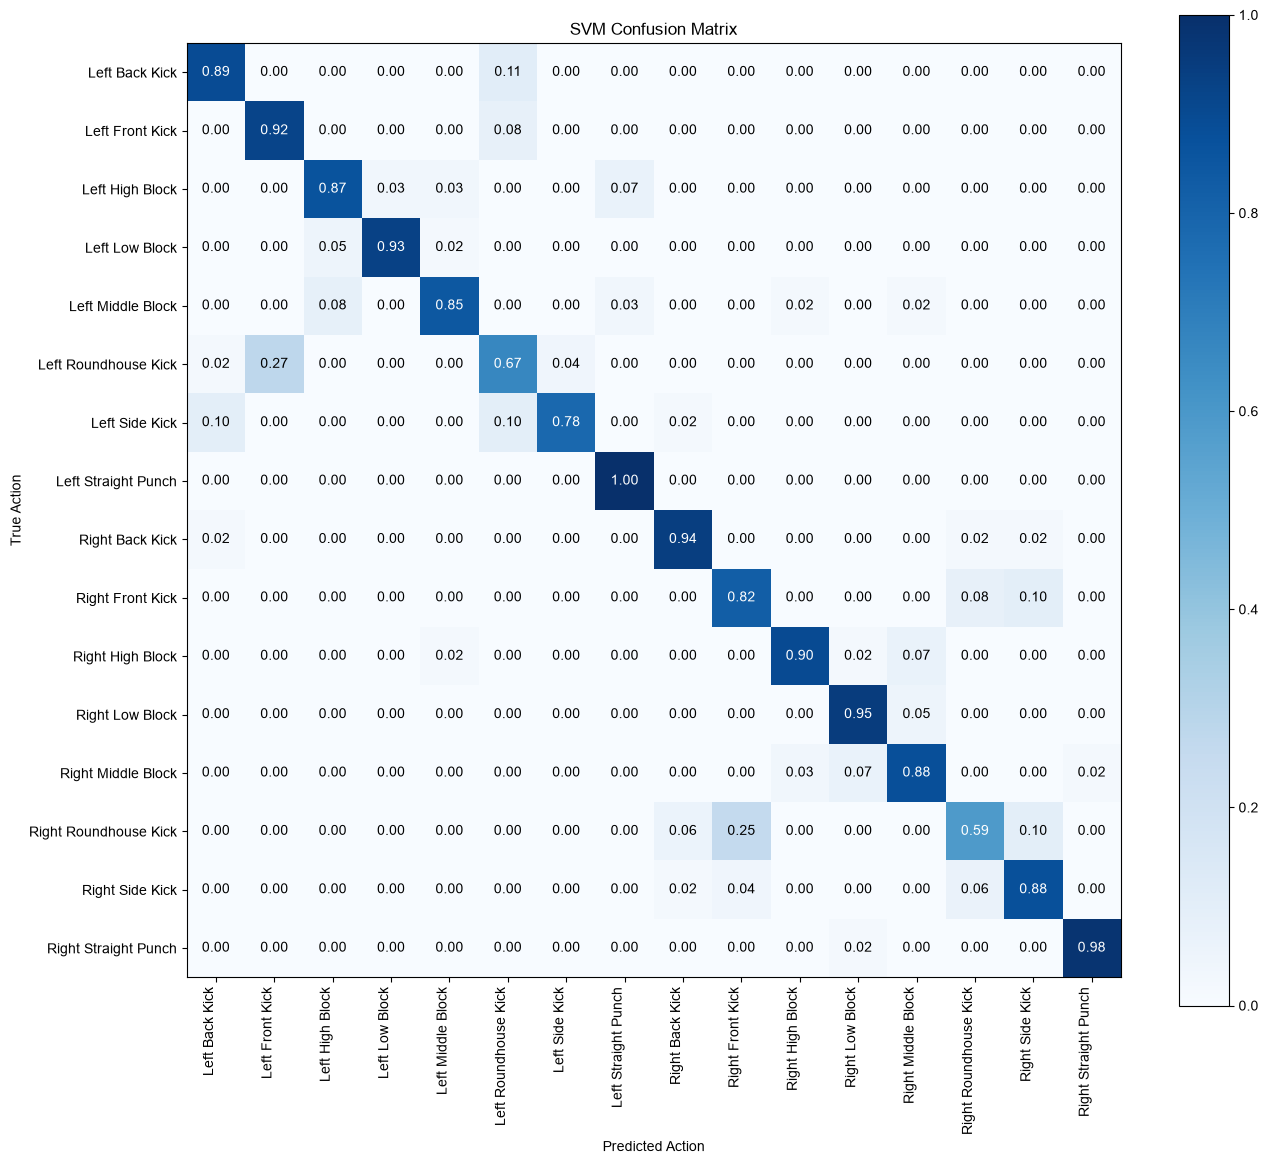

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# ====================== 1. 定义类别列表（固定顺序，不要修改！） ======================
CLASSES = [
    "Left Back Kick",
    "Left Front Kick",
    "Left High Block",
    "Left Low Block",
    "Left Middle Block",
    "Left Roundhouse Kick",
    "Left Side Kick",
    "Left Straight Punch",
    "Right Back Kick",
    "Right Front Kick",
    "Right High Block",
    "Right Low Block",
    "Right Middle Block",
    "Right Roundhouse Kick",
    "Right Side Kick",
    "Right Straight Punch"
]
# 动作字符串→数字标签映射
cls2id = {cls_name: idx for idx, cls_name in enumerate(CLASSES)}
# 生成标签向量
y = meta["action"].map(cls2id).values

# ====================== 2. 交叉验证函数（加入每折标准化） ======================
def run_cv(model_type, param_grid, F, y, meta, splits, class_weight=None, gs_scoring="f1_macro"):
    fold_rows = []              # 每折整体指标
    fold_perclass_list = []     # 每折每个类的指标
    fold_best_params = []       # 每折网格搜索最优参数
    yt_all, yp_all = [], []

    for sp in splits:
        # 按subject划分训练/测试（你的split格式）
        tr = meta["subject_key"].isin(sp["train"])
        te = meta["subject_key"].isin(sp["test"])
        Xtr_raw, Xte_raw = F[tr], F[te]
        ytr, yte = y[tr], y[te]

        # ========= 核心：每折单独标准化，只用训练集拟合scaler =========
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xtr_raw)
        Xte = scaler.transform(Xte_raw)

        # SVM模型
        model = SVC(class_weight=class_weight)
        gs = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=3,
            scoring=gs_scoring,
            n_jobs=1,  # n_jobs=1保证实验可复现
            refit=True
        )
        gs.fit(Xtr, ytr)
        pred = gs.predict(Xte)

        # 计算本折指标
        acc = accuracy_score(yte, pred)
        macro_f1 = f1_score(yte, pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(yte, pred, average="weighted", zero_division=0)
        w_prec = precision_score(yte, pred, average="weighted", zero_division=0)
        w_rec = recall_score(yte, pred, average="weighted", zero_division=0)

        fold_rows.append({
            "fold": sp["fold"],
            "accuracy": acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "weighted_precision": w_prec,
            "weighted_recall": w_rec,
        })
        fold_best_params.append({"fold": sp["fold"], "best_params": gs.best_params_})

        # 每折分类报告
        rep_fold = classification_report(
            yte, pred,
            labels=range(len(CLASSES)),
            target_names=CLASSES,
            output_dict=True,
            zero_division=0
        )
        for cls_name in CLASSES:
            fold_perclass_list.append({
                "fold": sp["fold"],
                "class": cls_name,
                "precision": rep_fold[cls_name]["precision"],
                "recall": rep_fold[cls_name]["recall"],
                "f1": rep_fold[cls_name]["f1-score"]
            })

        yt_all.append(yte)
        yp_all.append(pred)

    # 合并全部折的真实值与预测值，计算全局混淆矩阵
    yt = np.concatenate(yt_all)
    yp = np.concatenate(yp_all)

    agg = {
        "accuracy": accuracy_score(yt, yp),
        "macro_f1": f1_score(yt, yp, average="macro", zero_division=0),
        "weighted_f1": f1_score(yt, yp, average="weighted", zero_division=0),
        "weighted_precision": precision_score(yt, yp, average="weighted", zero_division=0),
        "weighted_recall": recall_score(yt, yp, average="weighted", zero_division=0),
    }
    cm = confusion_matrix(yt, yp, labels=range(len(CLASSES)))
    rep_global = classification_report(
        yt, yp,
        labels=range(len(CLASSES)),
        target_names=CLASSES,
        output_dict=True,
        zero_division=0
    )
    df_global_perclass = pd.DataFrame(rep_global).T
    df_folds = pd.DataFrame(fold_rows)
    df_fold_perclass = pd.DataFrame(fold_perclass_list)
    df_bestparams = pd.DataFrame(fold_best_params)

    return agg, cm, df_folds, df_global_perclass, df_fold_perclass, df_bestparams

# ====================== 3. 设置SVM参数网格，启动交叉验证 ======================
SVM_PARAM_GRID = [
    {"kernel": ["rbf"], "C": [0.1, 1, 10, 100], "gamma": [0.001, 0.01, 0.1, 1]}
]

# class_weight="balanced" 开启类别权重，缓解样本不均衡
agg, cm, df_folds, df_global_perclass, df_fold_perclass, df_bestparams = run_cv(
    model_type="svm",
    param_grid=SVM_PARAM_GRID,
    F=F,
    y=y,
    meta=meta,
    splits=splits,
    class_weight="balanced",
    gs_scoring="f1_macro"
)

# 保存混淆矩阵
np.save(RESULTS_DIR / "ml_svm_confusion.npy", cm)

# 输出每折结果，方便查看
print("===== 各折指标 =====")
display(df_folds)
print("\n===== 每折最优参数 =====")
display(df_bestparams)
print("\n===== 全局每类指标 =====")
display(df_global_perclass)

# ====================== 4. 混淆矩阵绘图函数 ======================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 10

def plot_confusion(cm_path, out_name, title="SVM Confusion Matrix", normalize=True):
    cm = np.load(cm_path)
    if normalize:
        # 按真实类别（行）归一化，每行总和=1（召回视角）
        cm = cm / cm.sum(axis=1, keepdims=True)
        cm = np.nan_to_num(cm)

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax)

    tick_pos = np.arange(len(CLASSES))
    ax.set_xticks(tick_pos)
    ax.set_yticks(tick_pos)
    ax.set_xticklabels(CLASSES, rotation=90, ha="right")
    ax.set_yticklabels(CLASSES)

    ax.set_xlabel("Predicted Action")
    ax.set_ylabel("True Action")
    ax.set_title(title)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text = ax.text(j, i, f"{cm[i,j]:.2f}",
                           ha="center", va="center",
                           color="white" if cm[i,j] > thresh else "black")
    fig.tight_layout(pad=2.0)
    fig.savefig(RESULTS_DIR / out_name, dpi=300, bbox_inches="tight")
    plt.show()

# 绘制混淆矩阵
plot_confusion(RESULTS_DIR / "ml_svm_confusion.npy", "confusion_heatmap_svm.png", title="SVM Confusion Matrix")


## 10 被试 × 动作可用性表（缺失/剔除情况）

In [34]:
# ========== 正确分类：按动作类型拆分，不是按左右拆分 ==========
KICK_ACTIONS = [
    "Left Back Kick",
    "Left Front Kick",
    "Left Roundhouse Kick",
    "Left Side Kick",
    "Right Back Kick",
    "Right Front Kick",
    "Right Roundhouse Kick",
    "Right Side Kick",
]

PUNCH_ACTIONS = [
    "Left High Block",
    "Left Low Block",
    "Left Middle Block",
    "Left Straight Punch",
    "Right High Block",
    "Right Low Block",
    "Right Middle Block",
    "Right Straight Punch",
]

def _subject_sort_key(key):
    region, sid = key.split("_", 1)
    return (region, int(sid))

def region_table(df, region, actions):
    sub = df[df["region"] == region]
    rows = []
    for sk in sorted(sub["subject_key"].unique(), key=_subject_sort_key):
        sk_data = sub[sub["subject_key"] == sk].drop_duplicates("id")
        cnt = sk_data.groupby("action").size()
        row = {"subject_key": sk, "total": int(cnt.sum())}
        for a in actions:
            row[a] = int(cnt.get(a, 0))
        rows.append(row)
    return pd.DataFrame(rows)

# ========== 生成两张统计表 ==========
# kick组受试者 → 统计8个踢击动作
table_kick = region_table(df, "kick", KICK_ACTIONS)
table_kick.to_csv(RESULTS_DIR / "metadata_kick.csv", index=False)
print(f"--- kick组 踢击动作 --- 缺失(0次)单元数：{(table_kick[KICK_ACTIONS] == 0).sum().sum()}")
display(table_kick)

# punch组受试者 → 统计8个格挡+拳击动作
table_punch = region_table(df, "punch", PUNCH_ACTIONS)
table_punch.to_csv(RESULTS_DIR / "metadata_punch.csv", index=False)
print(f"\n--- punch组 格挡拳击动作 --- 缺失(0次)单元数：{(table_punch[PUNCH_ACTIONS] == 0).sum().sum()}")
display(table_punch)


--- kick组 踢击动作 --- 缺失(0次)单元数：1


,subject_key,total,Left Back Kick,Left Front Kick,Left Roundhouse Kick,Left Side Kick,Right Back Kick,Right Front Kick,Right Roundhouse Kick,Right Side Kick
0,kick_1,54,0,5,6,10,8,7,9,9
1,kick_2,38,6,6,6,5,5,4,3,3
2,kick_3,46,5,6,6,4,6,6,6,7
3,kick_4,42,6,3,6,5,6,6,5,5
4,kick_5,44,6,6,6,5,6,6,6,3
5,kick_6,43,6,6,4,5,6,6,4,6
6,kick_7,37,4,4,4,4,4,6,6,5
7,kick_8,36,4,4,4,4,5,4,5,6
8,kick_9,37,5,4,4,5,4,6,5,4
9,kick_10,39,5,5,5,4,5,5,5,5



--- punch组 格挡拳击动作 --- 缺失(0次)单元数：0


,subject_key,total,Left High Block,Left Low Block,Left Middle Block,Left Straight Punch,Right High Block,Right Low Block,Right Middle Block,Right Straight Punch
0,punch_0,48,6,6,6,6,6,6,6,6
1,punch_1,46,5,6,6,6,6,6,5,6
2,punch_2,48,6,6,6,6,6,6,6,6
3,punch_3,48,6,6,6,6,6,6,6,6
4,punch_4,46,6,6,6,6,4,6,6,6
5,punch_5,45,6,5,6,6,4,6,6,6
6,punch_6,48,6,6,6,6,6,6,6,6
7,punch_7,48,6,6,6,6,6,6,6,6
8,punch_8,47,6,6,6,6,6,6,5,6
9,punch_9,48,6,6,6,6,6,6,6,6


## 11 测试集预览

In [24]:
import numpy as np

# 方案B：遍历splits，直接从meta查看每折测试集包含的动作类别
all_test_labels = []
for sp in splits:
    tr_subjects = sp["train"]
    te_subjects = sp["test"]
    te_mask = meta["subject_key"].isin(te_subjects)
    test_act = meta.loc[te_mask, "action"].values
    all_test_labels.extend(test_act)
    print(f"折 {sp['fold']} 测试集动作类别：{np.unique(test_act)}")

all_test_labels = np.array(all_test_labels)
print("\n===== 全部折合并后的测试集动作 =====")
print("所有测试集出现过的动作标签：", np.unique(all_test_labels))
uniq, cnt = np.unique(all_test_labels, return_counts=True)
for act, num in zip(uniq, cnt):
    print(f"{act} 测试样本数量：{num}")


折 0 测试集动作类别：['Left Back Kick' 'Left Front Kick' 'Left High Block' 'Left Low Block'
 'Left Middle Block' 'Left Roundhouse Kick' 'Left Side Kick'
 'Left Straight Punch' 'Right Back Kick' 'Right Front Kick'
 'Right High Block' 'Right Low Block' 'Right Middle Block'
 'Right Roundhouse Kick' 'Right Side Kick' 'Right Straight Punch']
折 1 测试集动作类别：['Left Back Kick' 'Left Front Kick' 'Left High Block' 'Left Low Block'
 'Left Middle Block' 'Left Roundhouse Kick' 'Left Side Kick'
 'Left Straight Punch' 'Right Back Kick' 'Right Front Kick'
 'Right High Block' 'Right Low Block' 'Right Middle Block'
 'Right Roundhouse Kick' 'Right Side Kick' 'Right Straight Punch']
折 2 测试集动作类别：['Left Back Kick' 'Left Front Kick' 'Left High Block' 'Left Low Block'
 'Left Middle Block' 'Left Roundhouse Kick' 'Left Side Kick'
 'Left Straight Punch' 'Right Back Kick' 'Right Front Kick'
 'Right High Block' 'Right Low Block' 'Right Middle Block'
 'Right Roundhouse Kick' 'Right Side Kick' 'Right Straight Punch']
折 3 测试集动作类